# Ocean.stats diagnostics (`ocean.stats.nc`)

MOM6 writes a per-timestep integration-diagnostics file, `ocean.stats` (plain text)
and `ocean.stats.nc` (its netCDF equivalent) -- energy, max CFL, mean sea level,
total mass, mean salinity/temperature, and their conservation errors over the
course of the run. This notebook finds `ocean.stats.nc` via the intake-esm
datastore and plots each diagnostic.

See discussion in [access-om3-paper-1#23](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/23)
and [access-nri-intake-catalog#682](https://github.com/ACCESS-NRI/access-nri-intake-catalog/issues/682).

The first draft of thie notebook was written with Claude (prompted by @chrisb13)

In [1]:
# These first two cells must be in all notebooks!
# It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in
# arguments externally using papermill (see mkfigs.sh for details)

# Set esm_file to the datastore for the main experiment of interest
esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test4-d28e0359/datastore.json"

# papermill settings. *No need to modify these if running interactively.*
papermill = False                      # `cwd` and `nbname` will be populated by papermill.
cwd = None                             # current working directory
nbname = None                          # notebook name


In [2]:
if not papermill:
    import nci_ipynb, os  # requires conda/analysis3-26.03 or later
    cwd = nci_ipynb.dir()
    nbname = nci_ipynb.name()
    os.chdir(cwd)
import mkfigs_bootstrap  # noqa: adds external/access-model-mkfigs/src to sys.path (stop-gap)
from mkfigs import MkmdWriter
mkmd = MkmdWriter(esm_file, nbname, str(cwd), pm=papermill)


In [12]:
import intake
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np


### Open the intake-esm datastore and find `ocean.stats.nc`

In [5]:
COLUMNS_WITH_ITERABLES = [
    "variable",
    "variable_long_name",
    "variable_standard_name",
    "variable_cell_methods",
    "variable_units",
]

datastore = intake.open_esm_datastore(esm_file, columns_with_iterables=COLUMNS_WITH_ITERABLES)
datastore.search(filename="ocean.stats.nc").df


,filename,path,file_id,frequency,start_date,end_date,variable,variable_long_name,variable_standard_name,variable_cell_methods,variable_units,realm,temporal_label
0,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:366,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown
1,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:366,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown
2,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:367,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown
3,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:366,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown
4,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:366,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:366,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown
62,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:367,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown
63,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:366,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown
64,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:366,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown


### Load `ocean.stats.nc`

`ocean.stats.nc`'s `Time` variable has a less than useful format so we use a workaround (see discussion
[access-nri-intake-catalog#682](https://github.com/ACCESS-NRI/access-nri-intake-catalog/issues/682#issuecomment-5578388398):
`datastore.to_dask(xarray_open_kwargs={"decode_times": False})`. 

In [10]:
#Running:
#ocean_stats = datastore.search(filename="ocean.stats.nc").to_dask(    xarray_open_kwargs=dict(decode_times=False))
#ocean_stats

#for /g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test4-d28e0359/datastore.json
#I get the classic:
#ValueError: Expected exactly one dataset. Received 2 datasets. Please refine your search on file_id or use `.to_dataset_dict()`.

datastore.search(filename="ocean.stats.nc").df["file_id"].unique()

matches = datastore.search(filename="ocean.stats.nc").df

matches[["file_id", "path"]].drop_duplicates()
for file_id, group in matches.groupby("file_id"):
    print("\n", file_id)
    print(group["path"].iloc[0])


 ocean.fx.Interface:76.Layer:75.Time:366
/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test4-d28e0359/output000/ocean.stats.nc

 ocean.fx.Interface:76.Layer:75.Time:367
/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test4-d28e0359/output002/ocean.stats.nc


In [ ]:
#i.e. for `MC_25km_jra_iaf+wombatlite-test4-d28e0359` we have two datasets...

In [15]:
# Remove the existing Time indexes so xarray doesn't try to align them.
ds000 = ocean_stats_000.reset_index("Time", drop=True)
ds002 = ocean_stats_002.reset_index("Time", drop=True)

# Concatenate the two runs end-to-end along Time.
ocean_stats = xr.concat(
    [ds000, ds002],
    dim="Time",
    data_vars="all",
    coords="minimal",
    compat="override",
    join="override",
)

# Make a new continuous elapsed-time coordinate.
time000 = ocean_stats_000["Time"].values
time002 = ocean_stats_002["Time"].values

# Offset the second run so that it starts immediately after the first.
dt = np.median(np.diff(time000))

time002_continuous = time002 - time002[0] + time000[-1] + dt

new_time = np.concatenate([time000, time002_continuous])

ocean_stats = ocean_stats.assign_coords(Time=new_time)

### Plot each diagnostic over the run

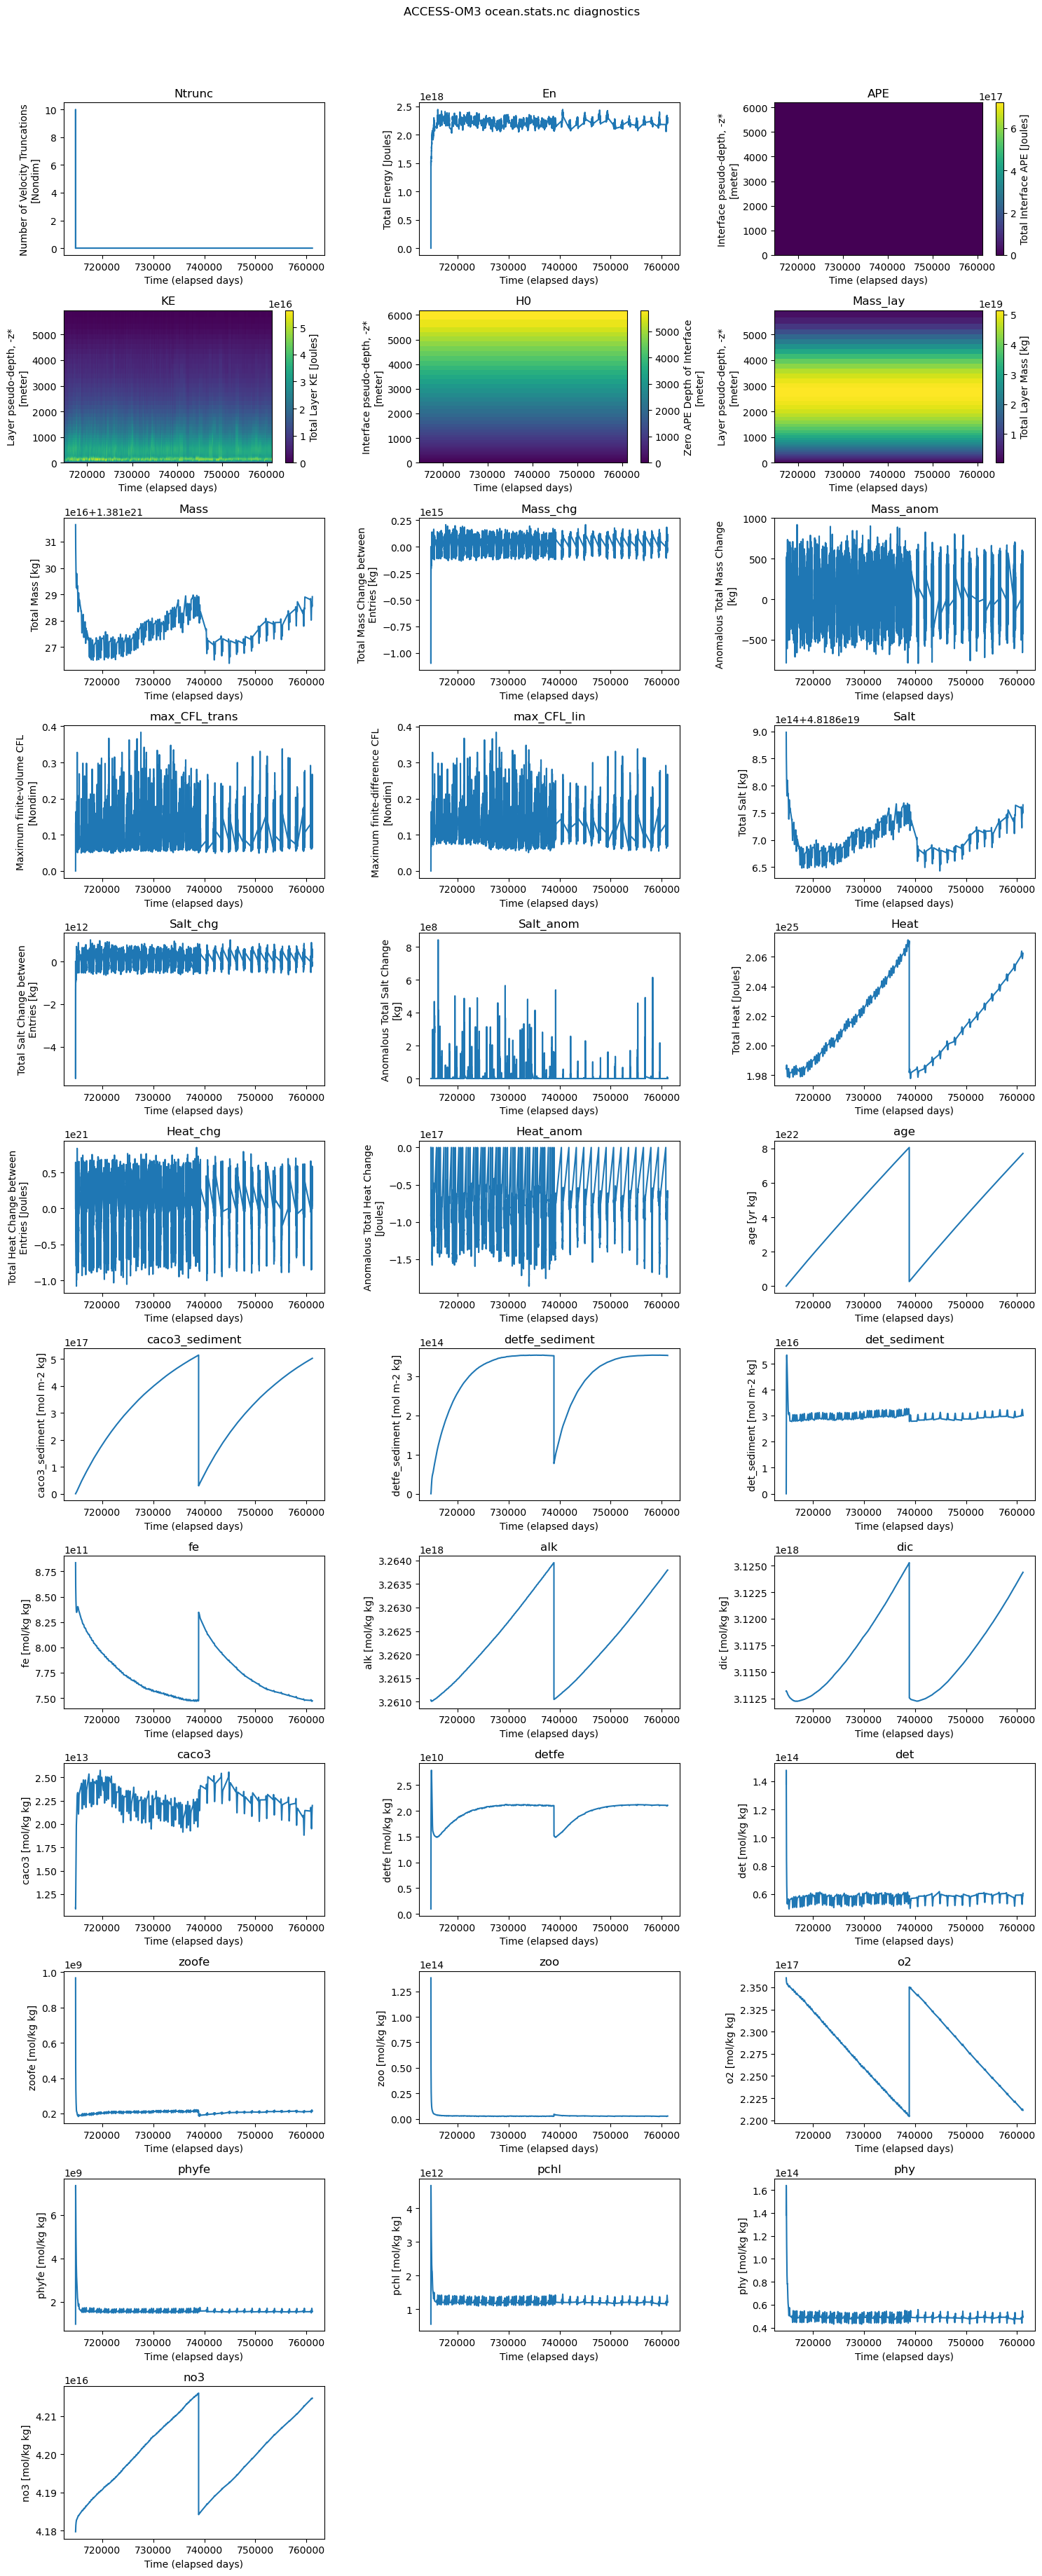

In [16]:
data_vars = [v for v in ocean_stats.data_vars if "Time" in ocean_stats[v].dims]

ncols = 3
nrows = -(-len(data_vars) // ncols)  # ceil division
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows), squeeze=False)

for ax, var in zip(axes.flat, data_vars):
    ocean_stats[var].plot(ax=ax, x="Time")
    ax.set_title(var)
    ax.set_xlabel("Time (elapsed days)")

for ax in axes.flat[len(data_vars):]:
    ax.axis("off")

fig.suptitle("ACCESS-OM3 ocean.stats.nc diagnostics", y=1.02)
fig.tight_layout()


In [18]:
# mkmd.savefig(fig, title, caption, dpi=100)
# Save figure and append to markdown summary.
mkmd.savefig(
    fig,
    "Ocean.stats diagnostics",
    "MOM6 integration diagnostics from ocean.stats.nc (energy, max CFL, mean sea "
    "level, total mass, mean salinity/temperature, and their conservation errors) "
    "over the course of the run.",
    dpi=150,
)
